# Работа 1

Построить схему и численное решение для уравнения Лапласа (при $ S = 0 $) внутри квадратной области $ 0 \leq x \leq 1 $, $ 0 \leq y \leq 1 $. Использовать один из следующих итерационных методов: Якоби, Гаусс-Зейдель или SOR.  
Граничные условия представлены на рисунке, более подробная информация по реализации содержится в файле [Lecture-2-2017.pdf](https://drive.google.com/file/d/1j05F6IkJgbnxEAizzUfEtr5cw633zx_v/view) (в разделе Steady State).

Уравнение Лапласа:

$$
\frac{\partial^2 f}{\partial x^2} + \frac{\partial^2 f}{\partial y^2} = S
$$

Итерация методом Якоби:

$$
f_{i,j}^{\alpha+1} = \frac{1}{4} \left( f_{i+1,j}^{\alpha} + f_{i-1,j}^{\alpha} + f_{i,j-1}^{\alpha} + f_{i,j+1}^{\alpha} - h^2 S_{i,j} \right)
\tag{1}
$$

<div align="center">
  <img src="./work_1.png" alt="">
</div>


In [77]:
import matplotlib.pyplot as plt
import numpy as np


In [78]:
# Параметры сетки

x_0, y_0 = 0.0, 0.0
x_1, y_1 = 1.0, 1.0

x_len = np.abs(x_1 - x_0)
y_len = np.abs(y_1 - y_0)

if x_len != y_len:
  raise ValueError(f"x_len ({x_len}) != y_len ({y_len}), сетка неоднородна!")

grid_len = x_len

N = 50  # количество узлов
h = grid_len / (N - 1)  # шаг сетки

# Создание сетки
x = np.linspace(x_0, x_1, N)
y = np.linspace(y_0, y_1, N)


In [79]:
# Инициализация функции f
f = np.zeros((N, N))

# Установка граничных условий

# Верхняя и нижняя стенки: f'y = 0 (неймановские условия)
# Используем односторонние разности
f[0, :] = f[1, :]  # нижняя стенка
f[-1, :] = f[-2, :]  # верхняя стенка

# Левая стенка: f'x = 0
f[:, 0] = f[:, 1]

# Правая стенка: смешанные условия Дирихле
quarter = N // 4
f[:, -1] = 1.0  # всё: f = 1, кроме:
f[-quarter:, -1] = 0.0  # верхняя четверть: f = 0
f[:quarter, -1] = 0.0  # нижняя четверть: f = 0

In [80]:
# Параметры итерационного процесса
MAX_ITERATION = 10000
TOLERANCE = 1e-6

In [81]:
def SolveLaplaceGaussSeidel(f: np.ndarray) -> np.ndarray:
  """
  Метод Гаусса-Зейделя

  Args:
      f (np.ndarray): изначальная сетка функции f

  Returns:
      np.ndarray: конечный результат
  """

  f_new = f.copy()

  for iteration in range(MAX_ITERATION):
    max_diff = 0.0

    for i in range(1, N - 1):
      for j in range(1, N - 1):
        # основная формула Гаусса-Зейделя для уравнения Лапласа
        f_new[i, j] = 0.25 * (
          f_new[i + 1, j] + f_new[i - 1, j] + f_new[i, j + 1] + f_new[i, j - 1]
        )

        # обновление максимального изменения
        diff = abs(f_new[i, j] - f[i, j])
        max_diff = max(max_diff, diff)

    # Обновление массива
    f[:, :] = f_new[:, :]

    # применение граничных условий на каждой итерации
    f[0, :] = f[1, :]  # нижняя стенка
    f[-1, :] = f[-2, :]  # верхняя стенка
    f[:, 0] = f[:, 1]  # левая стенка

    # правая стенка:
    f[:, -1] = 1.0
    f[-quarter:, -1] = 0.0
    f[:quarter, -1] = 0.0

    if max_diff < TOLERANCE:
      print(f"Сходимость достигнута на итерации {iteration}")
      break

  return f

Сходимость достигнута на итерации 1743


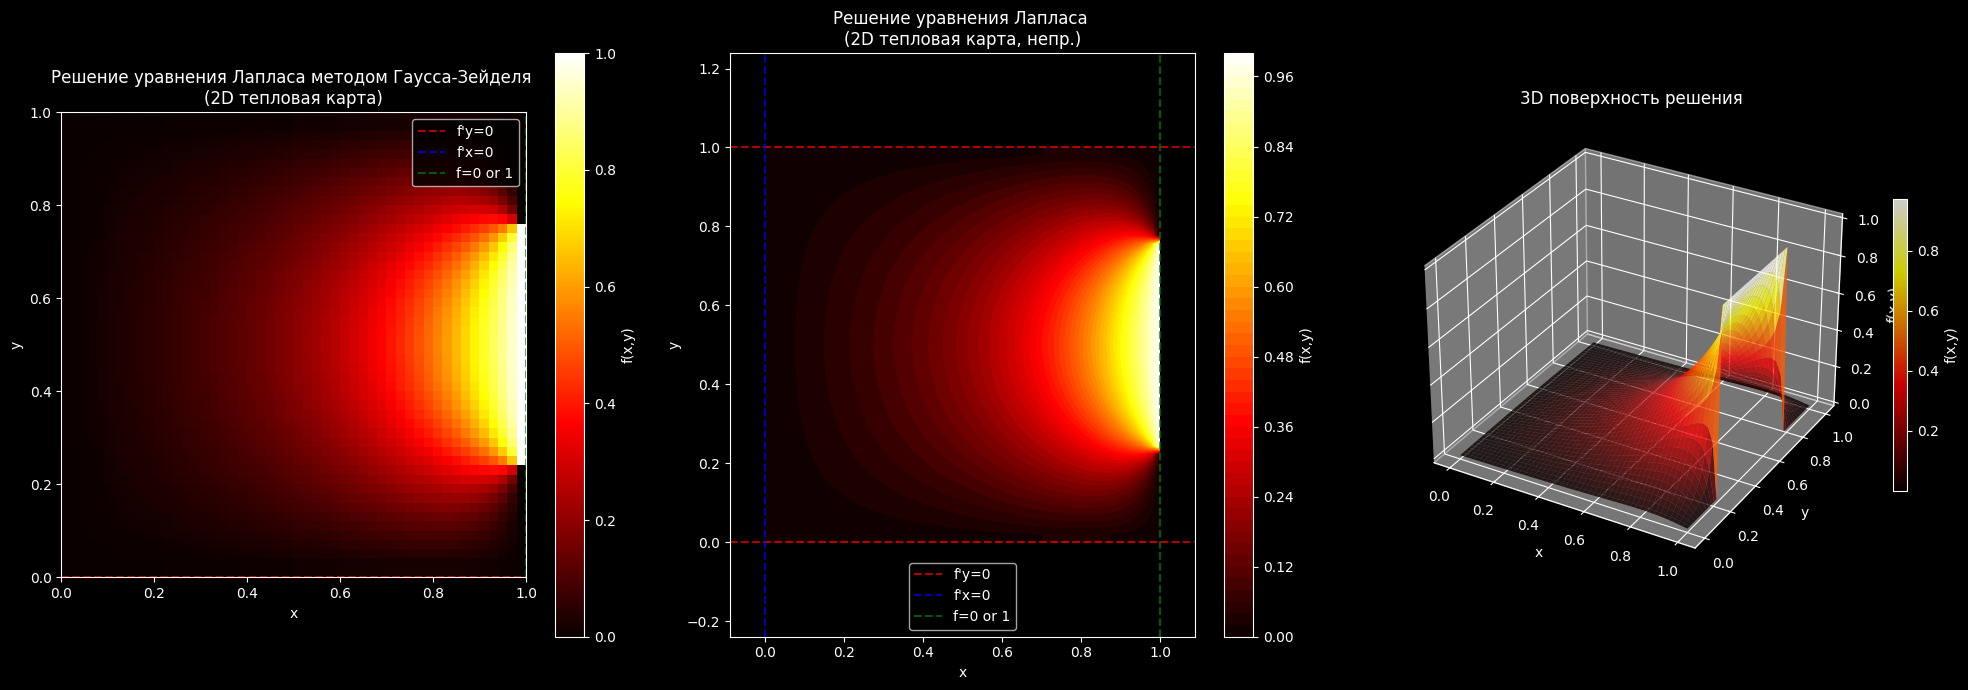

In [82]:
f = SolveLaplaceGaussSeidel(f)

fig = plt.figure(figsize=(20, 7))

# дискретная 2D тепловая карта
plt.subplot(1, 3, 1)
im = plt.imshow(f, extent=(0, 1, 0, 1), origin="lower", cmap="hot")
plt.colorbar(im, label="f(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Решение уравнения Лапласа методом Гаусса-Зейделя \n(2D тепловая карта)")

plt.axhline(y=0, color="red", linestyle="--", alpha=0.7, label="f'y=0")
plt.axhline(y=1, color="red", linestyle="--", alpha=0.7)
plt.axvline(x=0, color="blue", linestyle="--", alpha=0.7, label="f'x=0")
plt.axvline(x=1, color="green", linestyle="--", alpha=0.7, label="f=0 or 1")

plt.legend()

# непрерывная 2D тепловая карта (интерполяция)
plt.subplot(1, 3, 2)
X, Y = np.meshgrid(x, y)
contour = plt.contourf(X, Y, f, levels=50, cmap="hot")
plt.colorbar(contour, label="f(x,y)")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Решение уравнения Лапласа \n(2D тепловая карта, непр.)")
plt.axis("equal")

# граничные условия (визуализация)
plt.axhline(y=0, color="red", linestyle="--", alpha=0.7, label="f'y=0")
plt.axhline(y=1, color="red", linestyle="--", alpha=0.7)
plt.axvline(x=0, color="blue", linestyle="--", alpha=0.7, label="f'x=0")
plt.axvline(x=1, color="green", linestyle="--", alpha=0.7, label="f=0 or 1")

plt.legend()

# 3D поверхность
ax = fig.add_subplot(1, 3, 3, projection="3d")
surf = ax.plot_surface(X, Y, f, alpha=0.8, cmap="hot")

ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("f(x,y)")
ax.set_title("3D поверхность решения")

plt.colorbar(surf, ax=ax, shrink=0.5, aspect=20, label="f(x,y)")

plt.tight_layout()
plt.show()
